In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\HP\Downloads\StudentPerformanceFactors.csv")

In [3]:
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [5]:
df.rename(columns={'Access_to_Resources':'Resources','Extracurricular_Activities':'Extracurricular','Parental_Education_Level':'Parent Education'},inplace=True)
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Resources,Extracurricular,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parent Education,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df.isnull().sum()

Hours_Studied             0
Attendance                0
Parental_Involvement      0
Resources                 0
Extracurricular           0
Sleep_Hours               0
Previous_Scores           0
Motivation_Level          0
Internet_Access           0
Tutoring_Sessions         0
Family_Income             0
Teacher_Quality          78
School_Type               0
Peer_Influence            0
Physical_Activity         0
Learning_Disabilities     0
Parent Education         90
Distance_from_Home       67
Gender                    0
Exam_Score                0
dtype: int64

In [27]:
df.shape

(6607, 20)

In [7]:
df[['Teacher_Quality','Parent Education','Distance_from_Home']].isnull().mean()*100

Teacher_Quality       1.180566
Parent Education      1.362192
Distance_from_Home    1.014076
dtype: float64

In [8]:
cols=['Teacher_Quality','Parent Education','Distance_from_Home']
for i in cols:
    df[i]=df[i].fillna(df[i].mode()[0])

In [9]:
df.isnull().sum()

Hours_Studied            0
Attendance               0
Parental_Involvement     0
Resources                0
Extracurricular          0
Sleep_Hours              0
Previous_Scores          0
Motivation_Level         0
Internet_Access          0
Tutoring_Sessions        0
Family_Income            0
Teacher_Quality          0
School_Type              0
Peer_Influence           0
Physical_Activity        0
Learning_Disabilities    0
Parent Education         0
Distance_from_Home       0
Gender                   0
Exam_Score               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

Hours_Studied            41
Attendance               41
Parental_Involvement      3
Resources                 3
Extracurricular           2
Sleep_Hours               7
Previous_Scores          51
Motivation_Level          3
Internet_Access           2
Tutoring_Sessions         9
Family_Income             3
Teacher_Quality           3
School_Type               2
Peer_Influence            3
Physical_Activity         7
Learning_Disabilities     2
Parent Education          3
Distance_from_Home        3
Gender                    2
Exam_Score               45
dtype: int64

In [14]:
cat=df.select_dtypes(include='object').columns
for i in cat:
    print(i, ":",df[i].unique())

Parental_Involvement : ['Low' 'Medium' 'High']
Resources : ['High' 'Medium' 'Low']
Extracurricular : ['No' 'Yes']
Motivation_Level : ['Low' 'Medium' 'High']
Internet_Access : ['Yes' 'No']
Family_Income : ['Low' 'Medium' 'High']
Teacher_Quality : ['Medium' 'High' 'Low']
School_Type : ['Public' 'Private']
Peer_Influence : ['Positive' 'Negative' 'Neutral']
Learning_Disabilities : ['No' 'Yes']
Parent Education : ['High School' 'College' 'Postgraduate']
Distance_from_Home : ['Near' 'Moderate' 'Far']
Gender : ['Male' 'Female']


In [15]:
for col in cat:
    print("\n", col)
    print(df[col].value_counts())


 Parental_Involvement
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

 Resources
Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

 Extracurricular
Extracurricular
Yes    3938
No     2669
Name: count, dtype: int64

 Motivation_Level
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

 Internet_Access
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

 Family_Income
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

 Teacher_Quality
Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64

 School_Type
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

 Peer_Influence
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

 Learning_Disabilities
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

 Parent Education
Par

In [16]:
for col in cat:
    print("\n", col)
    print(df[col].value_counts(normalize=True)*100)


 Parental_Involvement
Parental_Involvement
Medium    50.885425
High      28.878462
Low       20.236113
Name: proportion, dtype: float64

 Resources
Resources
Medium    50.234600
High      29.892538
Low       19.872862
Name: proportion, dtype: float64

 Extracurricular
Extracurricular
Yes    59.603451
No     40.396549
Name: proportion, dtype: float64

 Motivation_Level
Motivation_Level
Medium    50.718934
Low       29.317391
High      19.963675
Name: proportion, dtype: float64

 Internet_Access
Internet_Access
Yes    92.447404
No      7.552596
Name: proportion, dtype: float64

 Family_Income
Family_Income
Low       40.441956
Medium    40.351143
High      19.206902
Name: proportion, dtype: float64

 Teacher_Quality
Teacher_Quality
Medium    60.587256
High      29.468745
Low        9.943999
Name: proportion, dtype: float64

 School_Type
School_Type
Public     69.592856
Private    30.407144
Name: proportion, dtype: float64

 Peer_Influence
Peer_Influence
Positive    39.927350
Neutral     

Text(0.5, 1.0, 'Count Plot')

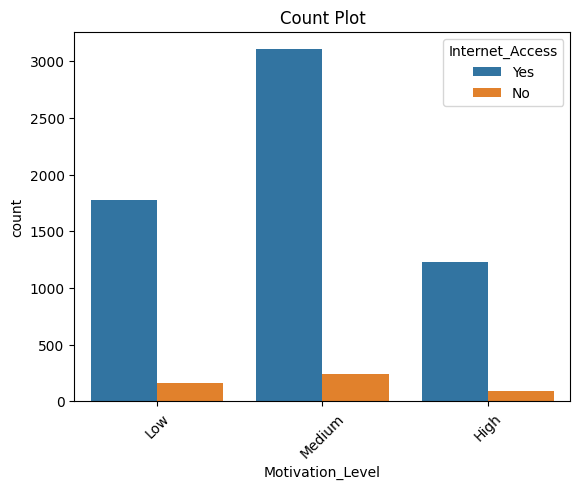

In [17]:
sns.countplot(x='Motivation_Level',data=df,hue='Internet_Access')
plt.xticks(rotation=45)
plt.title("Count Plot")

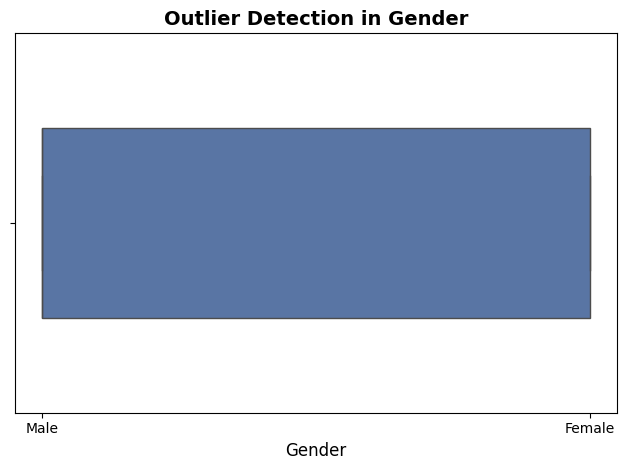

In [18]:
sns.boxplot(
        x=df[col],
        color="#4C72B0",      # single professional color
        width=0.5,
        fliersize=4           # outlier dot size
    )
    
plt.title(f"Outlier Detection in {col}", fontsize=14, fontweight='bold')
plt.xlabel(col, fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
def outlier_percent(series):
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((series < lower) | (series > upper)).sum()
    
    percent = (outliers / len(series)) * 100
    
    return percent

In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].apply(lambda x: ((x < (x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25)))) | 
                              (x > (x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25))))).sum())

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

In [21]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

In [22]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].apply(lambda x: ((x < (x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25)))) | 
                              (x > (x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25))))).sum())

Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Tutoring_Sessions    0
Physical_Activity    0
Exam_Score           0
dtype: int64

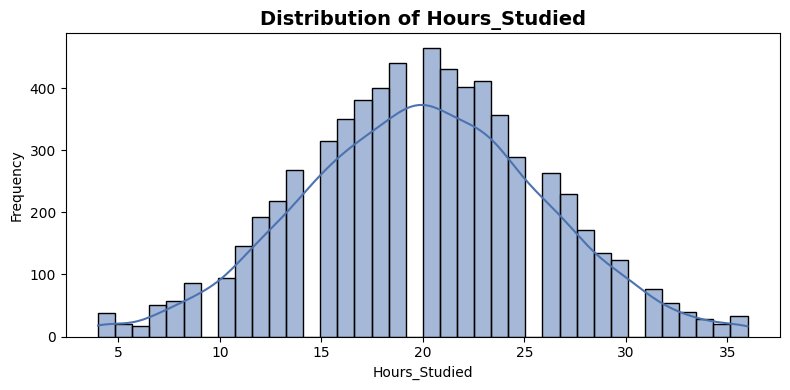

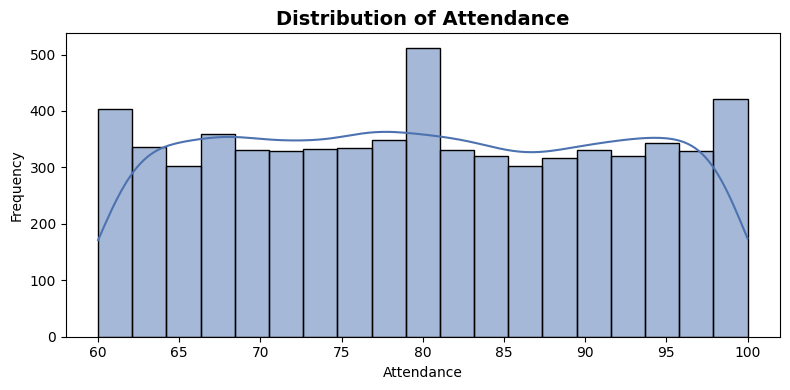

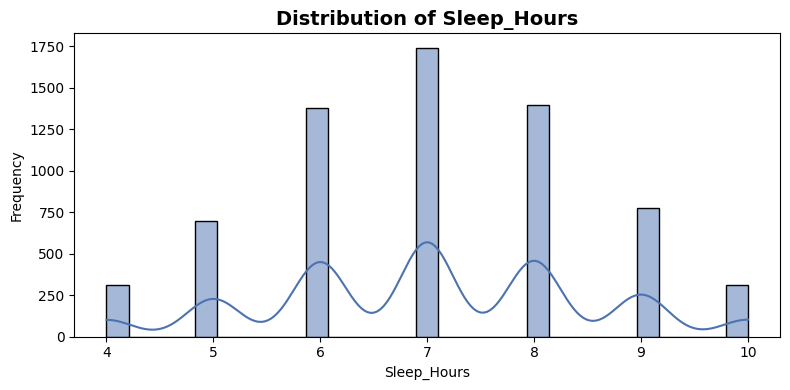

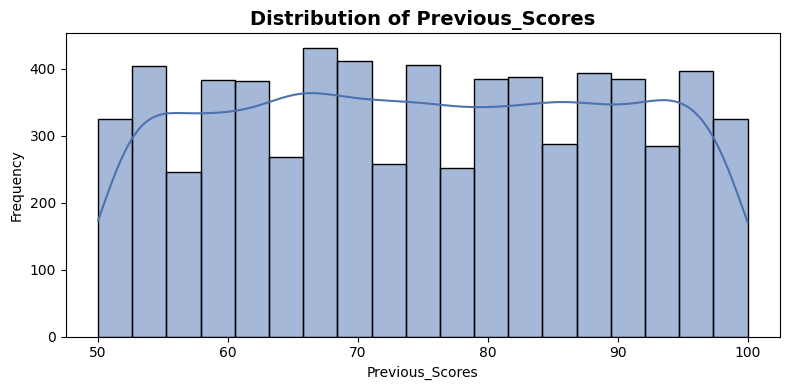

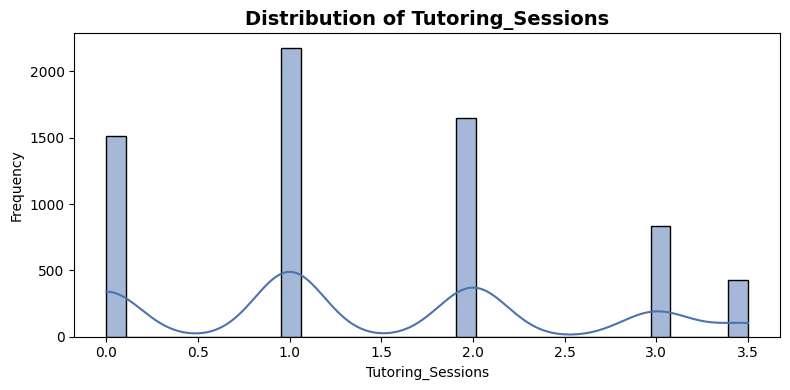

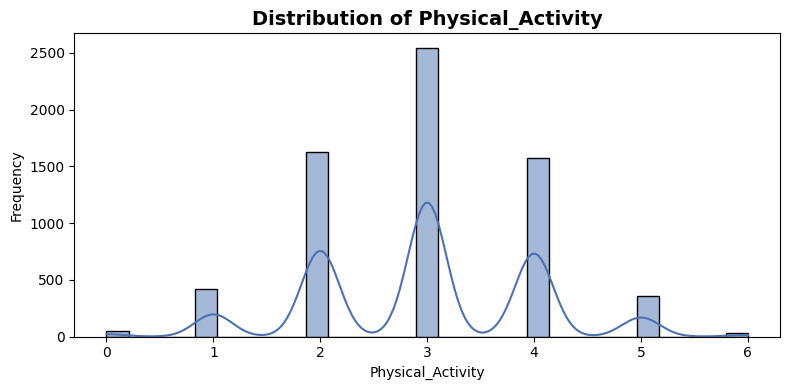

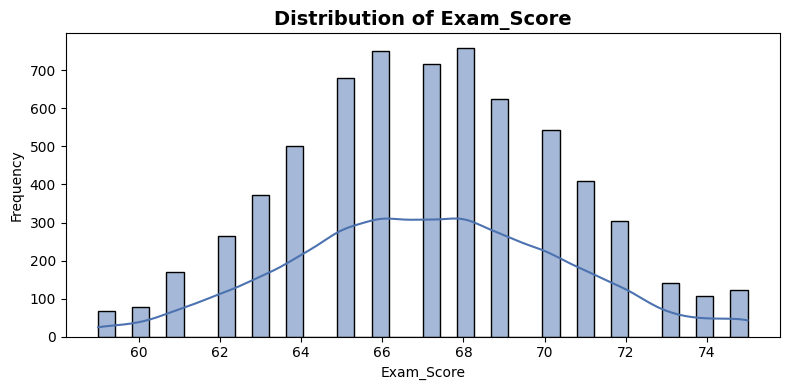

In [23]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col], kde=True, color="#4C72B0")
    
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

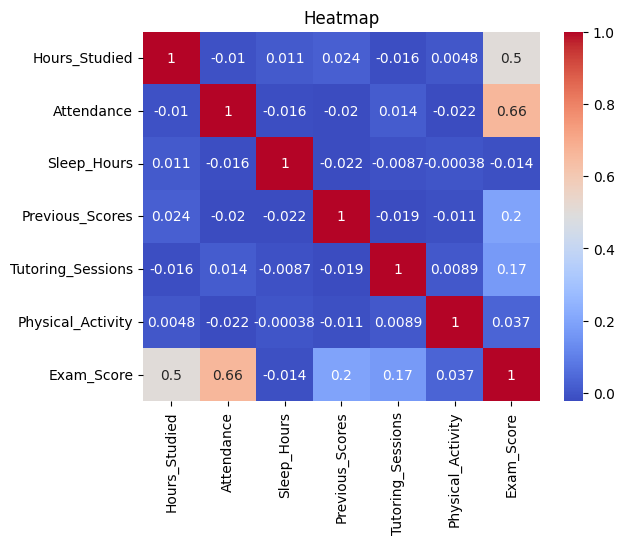

In [24]:
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Heatmap")
plt.show()

In [25]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Resources',
       'Extracurricular', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
       'Internet_Access', 'Tutoring_Sessions', 'Family_Income',
       'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity',
       'Learning_Disabilities', 'Parent Education', 'Distance_from_Home',
       'Gender', 'Exam_Score'],
      dtype='object')

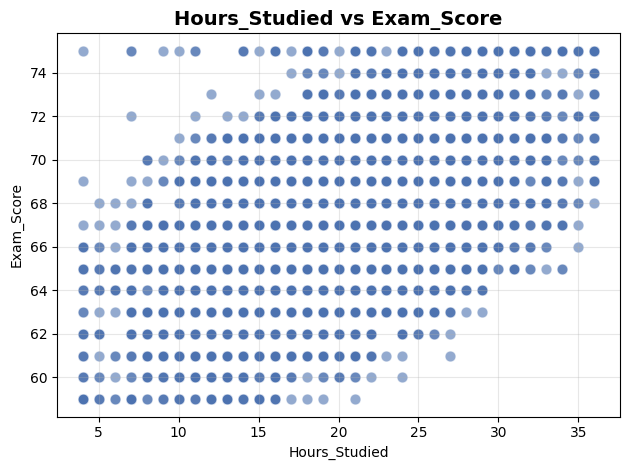

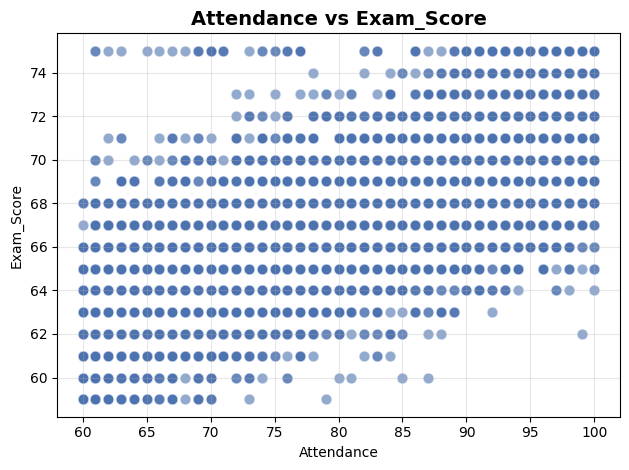

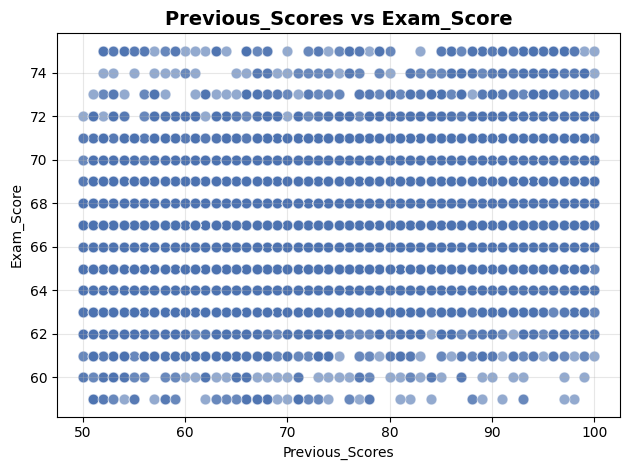

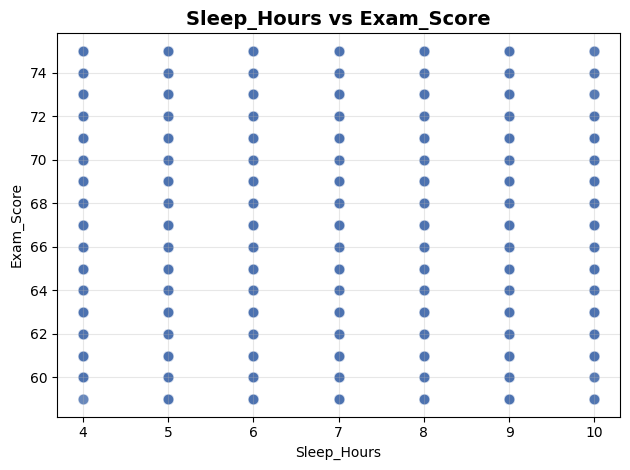

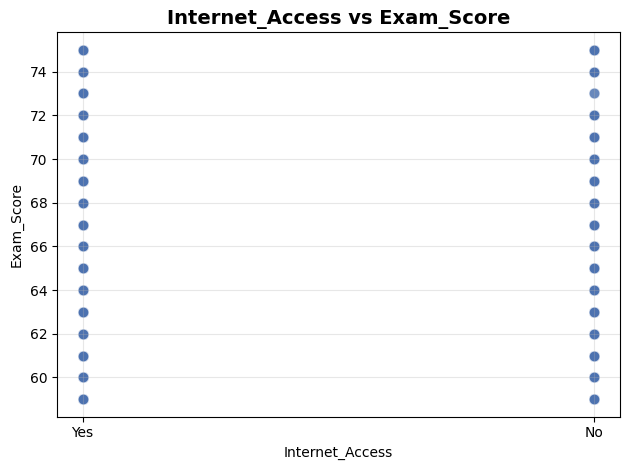

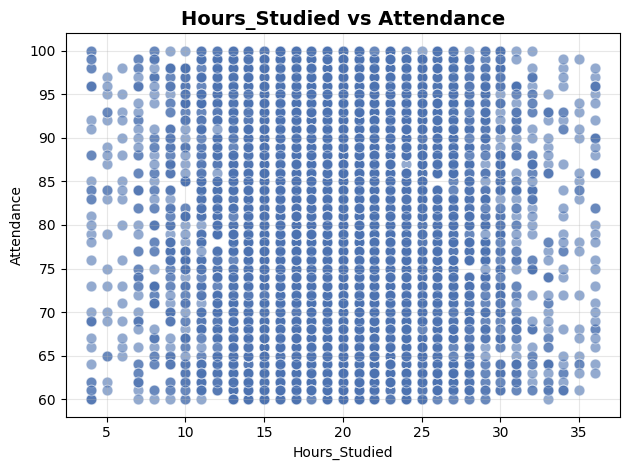

In [26]:

pairs = [
    ('Hours_Studied', 'Exam_Score'),
    ('Attendance', 'Exam_Score'),
    ('Previous_Scores', 'Exam_Score'),
    ('Sleep_Hours', 'Exam_Score'),
    ('Internet_Access', 'Exam_Score'),
    ('Hours_Studied', 'Attendance')
]

for x_col, y_col in pairs:
    sns.scatterplot(
        x=x_col,
        y=y_col,
        data=df,
        color="#4C72B0",
        s=60,
        alpha=0.6
    )
    plt.title(f"{x_col} vs {y_col}", fontsize=14, fontweight='bold')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()